In [41]:
import tensorflow as tf
from livelossplot import PlotLossesKeras
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from utils.load import load_data
from utils.handlers import get_average

In [42]:
from statistics import mean




In [43]:
def fix_img(path):
    df = load_data(path)
    arr = df['images'].astype('int')
    broken_pixels = [{0}, {255}]
    for i, image in enumerate(arr):
        mx_x, mx_y, _ = image.shape
        for ii, col in enumerate(image):
            for iii, jjj in enumerate(col):

                if set(jjj) in broken_pixels:
                    arr[i, ii, iii] = get_average(ii, iii, mx_x, mx_y, arr[i])
    return df, arr

In [44]:
df, arr = fix_img('data_train')

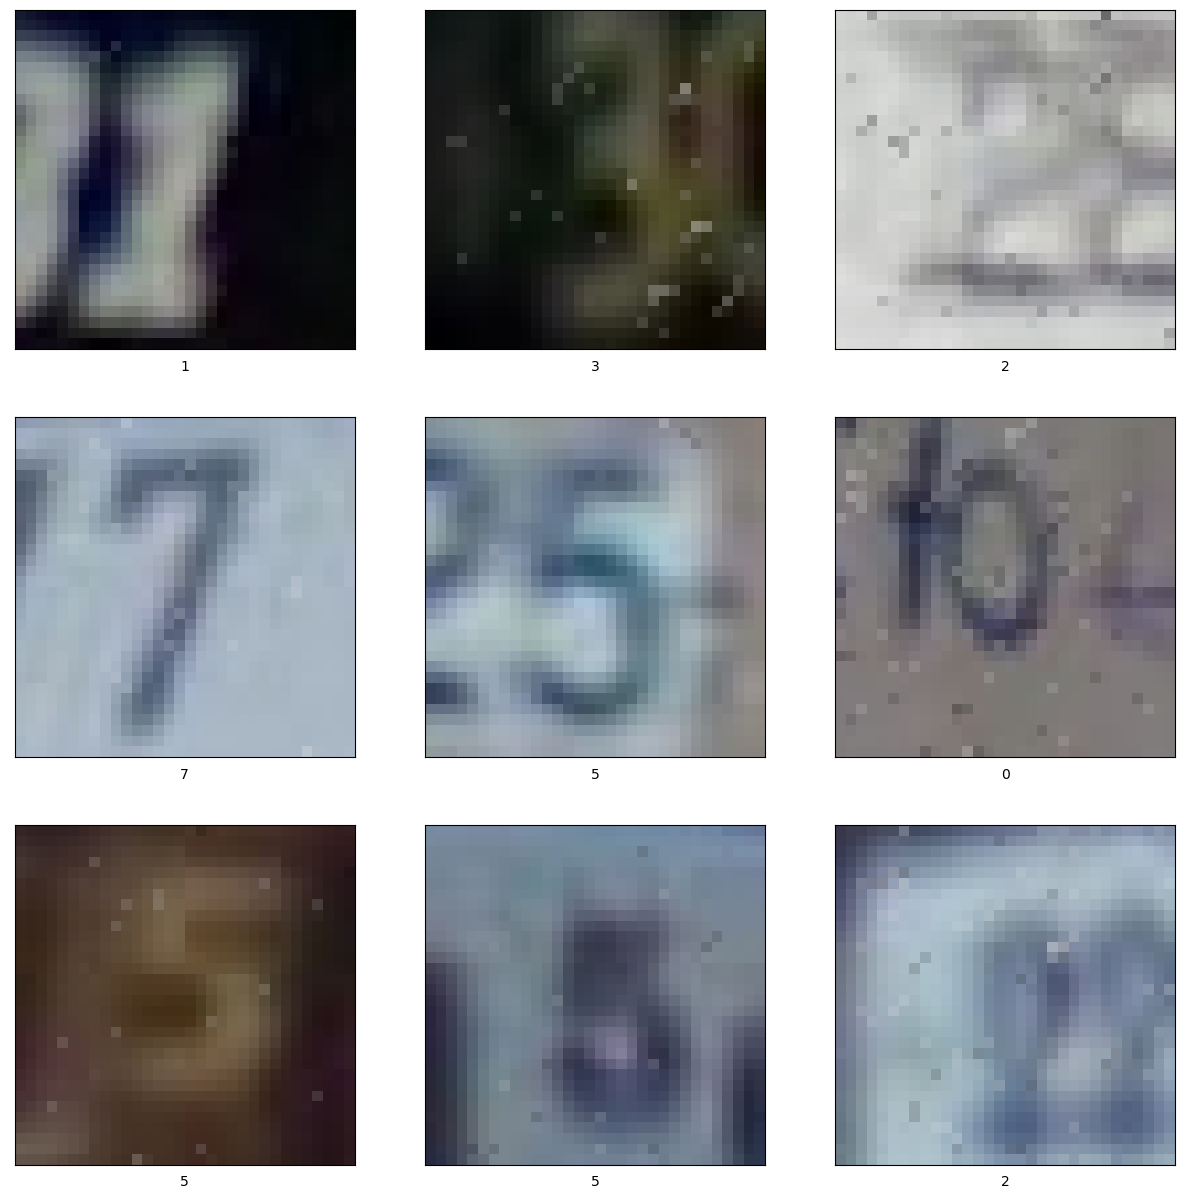

In [45]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arr[i]))
    plt.xlabel(df['labels'][i])
plt.show()

In [6]:
from PIL import Image, ImageEnhance
def enchance(_img): # TODO: сделать чтобы созранялась размерность
    img = Image.fromarray(np.uint8(_img * 255))
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(7)
    enhancer2 = ImageEnhance.Sharpness(img)
    img = enhancer2.enhance(7)
    return np.asarray(img)

def get_bw_filter(img: np.ndarray) -> np.ndarray:
    x, y, _ = img.shape
    for loc_i in range(x):
        for loc_j in range(y):
            img[loc_i, loc_j] = np.array([mean(img[loc_i, loc_j])] * 3)
    return img


In [7]:
arr = np.array([enchance(i) for i in arr])
#arr = np.array([cv.cvtColor(np.uint8(i), cv.COLOR_BGR2GRAY) for i in arr])


In [8]:
"""from statistics import mean
for i, j in enumerate(arr):
    for ii, jj in enumerate(j):
        for iii, jjj in enumerate(jj):
            if list(jjj) in [[0, 0, 0], [255, 255, 255]]:
                for k in range(3):
                    try:
                        arr[i, ii, iii, k] = mean([arr[i, ii, iii + 1, k],
                                               arr[i, ii, iii - 1, k],
                                               arr[i, ii + 1, iii - 1, k],
                                               arr[i, ii + 1, iii + 1, k],
                                               arr[i, ii - 1, iii + 1, k],
                                               arr[i, ii - 1, iii - 1, k]])
                    except IndexError:
                        pass
"""

'from statistics import mean\nfor i, j in enumerate(arr):\n    for ii, jj in enumerate(j):\n        for iii, jjj in enumerate(jj):\n            if list(jjj) in [[0, 0, 0], [255, 255, 255]]:\n                for k in range(3):\n                    try:\n                        arr[i, ii, iii, k] = mean([arr[i, ii, iii + 1, k],\n                                               arr[i, ii, iii - 1, k],\n                                               arr[i, ii + 1, iii - 1, k],\n                                               arr[i, ii + 1, iii + 1, k],\n                                               arr[i, ii - 1, iii + 1, k],\n                                               arr[i, ii - 1, iii - 1, k]])\n                    except IndexError:\n                        pass\n'

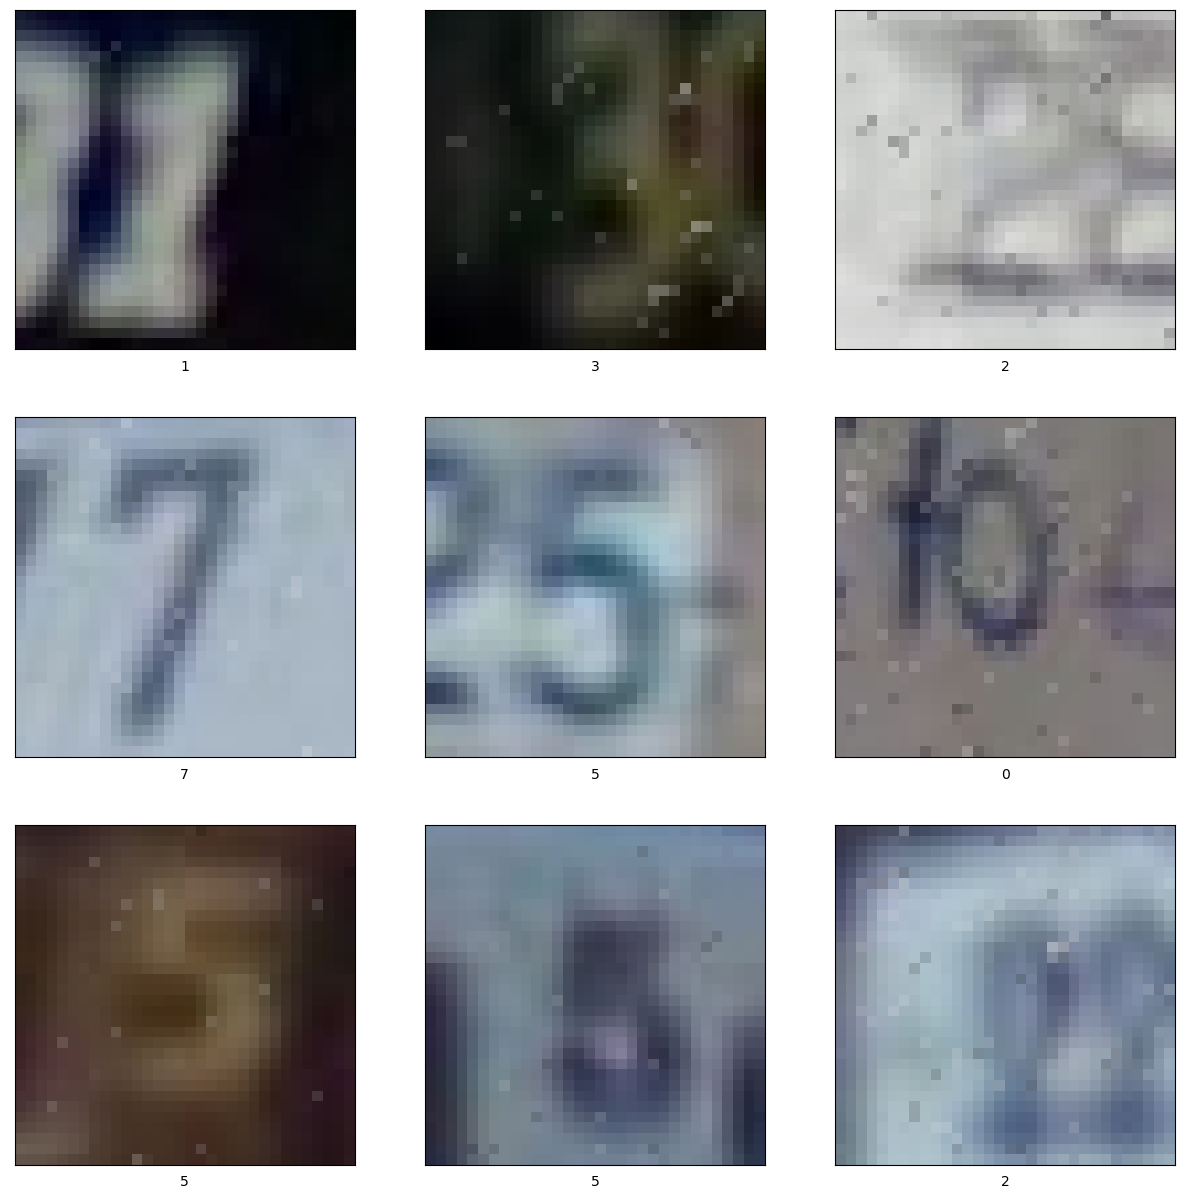

In [46]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arr[i]))
    plt.xlabel(df['labels'][i])
plt.show()

In [47]:
arr

array([[[[ 21,  27,  49],
         [ 18,  20,  44],
         [ 13,  13,  41],
         ...,
         [  0,   4,   6],
         [  0,   4,   4],
         [  0,   4,   3]],

        [[ 28,  36,  56],
         [ 26,  32,  56],
         [ 21,  25,  52],
         ...,
         [  1,   5,   8],
         [  0,   4,   4],
         [  0,   3,   2]],

        [[ 55,  64,  80],
         [ 54,  61,  81],
         [ 48,  54,  77],
         ...,
         [  1,   5,   8],
         [  0,   4,   5],
         [  1,   5,   4]],

        ...,

        [[ 55,  47,  57],
         [ 36,  31,  40],
         [ 19,  16,  24],
         ...,
         [  7,   8,   8],
         [  7,   9,   8],
         [  7,   8,   8]],

        [[ 18,   8,  22],
         [ 14,   7,  20],
         [  8,   4,  14],
         ...,
         [  8,   8,   7],
         [  8,   8,   8],
         [  7,   7,   7]],

        [[ 13,   5,  20],
         [ 14,   7,  20],
         [ 15,  11,  21],
         ...,
         [  9,   9,   9],
        

In [11]:
"""arr = arr / 255."""

'arr = arr / 255.'

In [48]:
from sklearn.model_selection import train_test_split

train_images, validation_images, train_labels, validation_labels = train_test_split(arr, df['labels'], test_size=0.01)

In [49]:
train_images.shape

(49500, 32, 32, 3)

In [50]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images,
                                                    train_labels))

val_dataset = tf.data.Dataset.from_tensor_slices((validation_images,
                                                  validation_labels))

In [51]:
input_shape = (32, 32, 3)
input_shape

(32, 32, 3)

In [52]:
batch_size = 256
train_dataset = train_dataset.shuffle(buffer_size = 1024, reshuffle_each_iteration=True, seed=123)
train_dataset = train_dataset.batch(batch_size)

val_dataset = val_dataset.batch(batch_size)

In [53]:
input_layer = tf.keras.layers.Input(shape=input_shape)

# Первый блок:
b1l1 = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(input_layer)
b1l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b1l1)
b1_output = tf.keras.layers.MaxPooling2D()(b1l2)

# Второй блок:
b2l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b1_output)
b2l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b2l1)

# Связываем эти 2 блока
b2b1_output = tf.keras.layers.add([b2l2, b1_output])

# Третий блок:
b3l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b2b1_output)
b3l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b3l1)

# Связываем эти 2 блока
block_3_output = tf.keras.layers.add([b3l2, b2b1_output])

b4l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_3_output)
b4l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b4l1)

block_4_output = tf.keras.layers.add([block_3_output, b4l2])

b5l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_4_output)
b5l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b5l1)

block_5_output = tf.keras.layers.add([block_4_output, b5l2])

b6l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_5_output)
b6l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b6l1)

block_6_output = tf.keras.layers.add([block_5_output, b6l2])


l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_6_output)
l2 = tf.keras.layers.GlobalAveragePooling2D()(l1)
l4 = tf.keras.layers.Dense(256, activation="relu")(l2)
l5 = tf.keras.layers.Dropout(.5)(l4)
outputs = tf.keras.layers.Dense(10)(l5)

In [54]:
model_resnet = tf.keras.Model(input_layer, outputs, name="resnet")

In [55]:
model_resnet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
model_resnet.summary()

Model: "resnet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_13 (Conv2D)             (None, 32, 32, 32)   896         ['input_2[0][0]']                
                                                                                                  
 conv2d_14 (Conv2D)             (None, 32, 32, 64)   18496       ['conv2d_13[0][0]']              
                                                                                                  
 max_pooling2d_1 (MaxPooling2D)  (None, 16, 16, 64)  0           ['conv2d_14[0][0]']              
                                                                                             

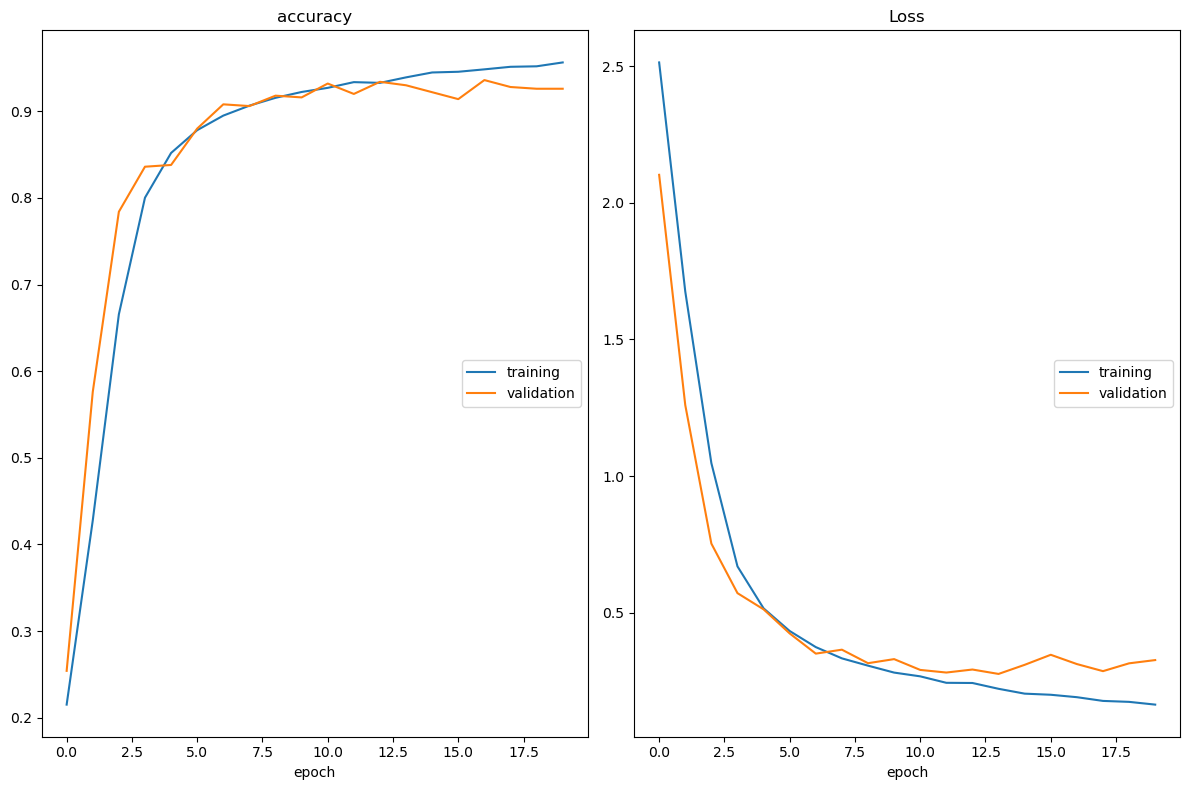

accuracy
	training         	 (min:    0.215, max:    0.956, cur:    0.956)
	validation       	 (min:    0.254, max:    0.936, cur:    0.926)
Loss
	training         	 (min:    0.164, max:    2.514, cur:    0.164)
	validation       	 (min:    0.276, max:    2.102, cur:    0.327)


In [56]:
model_resnethist = model_resnet.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[PlotLossesKeras()], verbose=False)

epo 14


In [21]:
model_resnethist.history

{'loss': [3.125415325164795,
  1.736344814300537,
  1.0820128917694092,
  0.6868746876716614,
  0.49192190170288086,
  0.4168049693107605,
  0.37134140729904175,
  0.33154475688934326,
  0.30606621503829956,
  0.2854370176792145,
  0.2609669268131256,
  0.24661296606063843,
  0.23104773461818695,
  0.21990492939949036,
  0.20361247658729553,
  0.18817049264907837,
  0.18778586387634277,
  0.16940832138061523,
  0.16095294058322906,
  0.15814556181430817],
 'accuracy': [0.20511111617088318,
  0.38880807161331177,
  0.6314343214035034,
  0.7868888974189758,
  0.8518585562705994,
  0.8786060810089111,
  0.8895757794380188,
  0.9036767482757568,
  0.9121615886688232,
  0.9187878966331482,
  0.9259393811225891,
  0.929595947265625,
  0.9344040155410767,
  0.9368484616279602,
  0.942242443561554,
  0.9459393620491028,
  0.9457777738571167,
  0.9521616101264954,
  0.9544040560722351,
  0.9540404081344604],
 'val_loss': [2.0461366176605225,
  1.523591160774231,
  0.7447668313980103,
  0.448392

In [63]:
dftest, arrtest = fix_img('data_test')
arrtest0 = arrtest

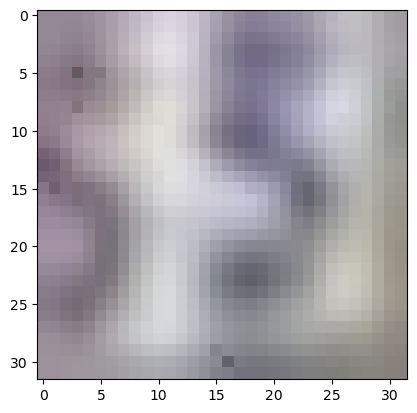

In [38]:
plt.imshow(arrtest0[67])

In [62]:

arrtest = np.array([enchance(i) for i in arrtest])

In [64]:
predictions = model_resnet.predict(arrtest)
predictions


782/782 [==============================] - 7s 9ms/step


array([[-7.1387944 ,  1.4268857 , -2.2871861 , ..., -1.478013  ,
        -7.9911003 ,  0.09240554],
       [-1.267347  ,  0.52994716, -2.6563237 , ..., -2.0053582 ,
        -0.27766263,  1.5846301 ],
       [-3.4323494 ,  6.8635488 , -1.3646834 , ...,  4.3499904 ,
        -2.9909072 , -0.22569439],
       ...,
       [ 9.664363  , -0.53714675, -2.2290173 , ..., -0.9461054 ,
        -2.9254048 , -0.11950498],
       [-2.3072555 , -3.7631855 ,  0.6734932 , ..., -4.368986  ,
        -0.9472639 , 10.572888  ],
       [-6.935859  ,  2.6926038 , 16.391619  , ..., -1.5116508 ,
        -5.4621506 , -5.662772  ]], dtype=float32)

In [65]:
classes = np.argmax(predictions, axis=1)
classes
# 5 4 1 ... 0 9 2

array([5, 4, 1, ..., 0, 9, 2])

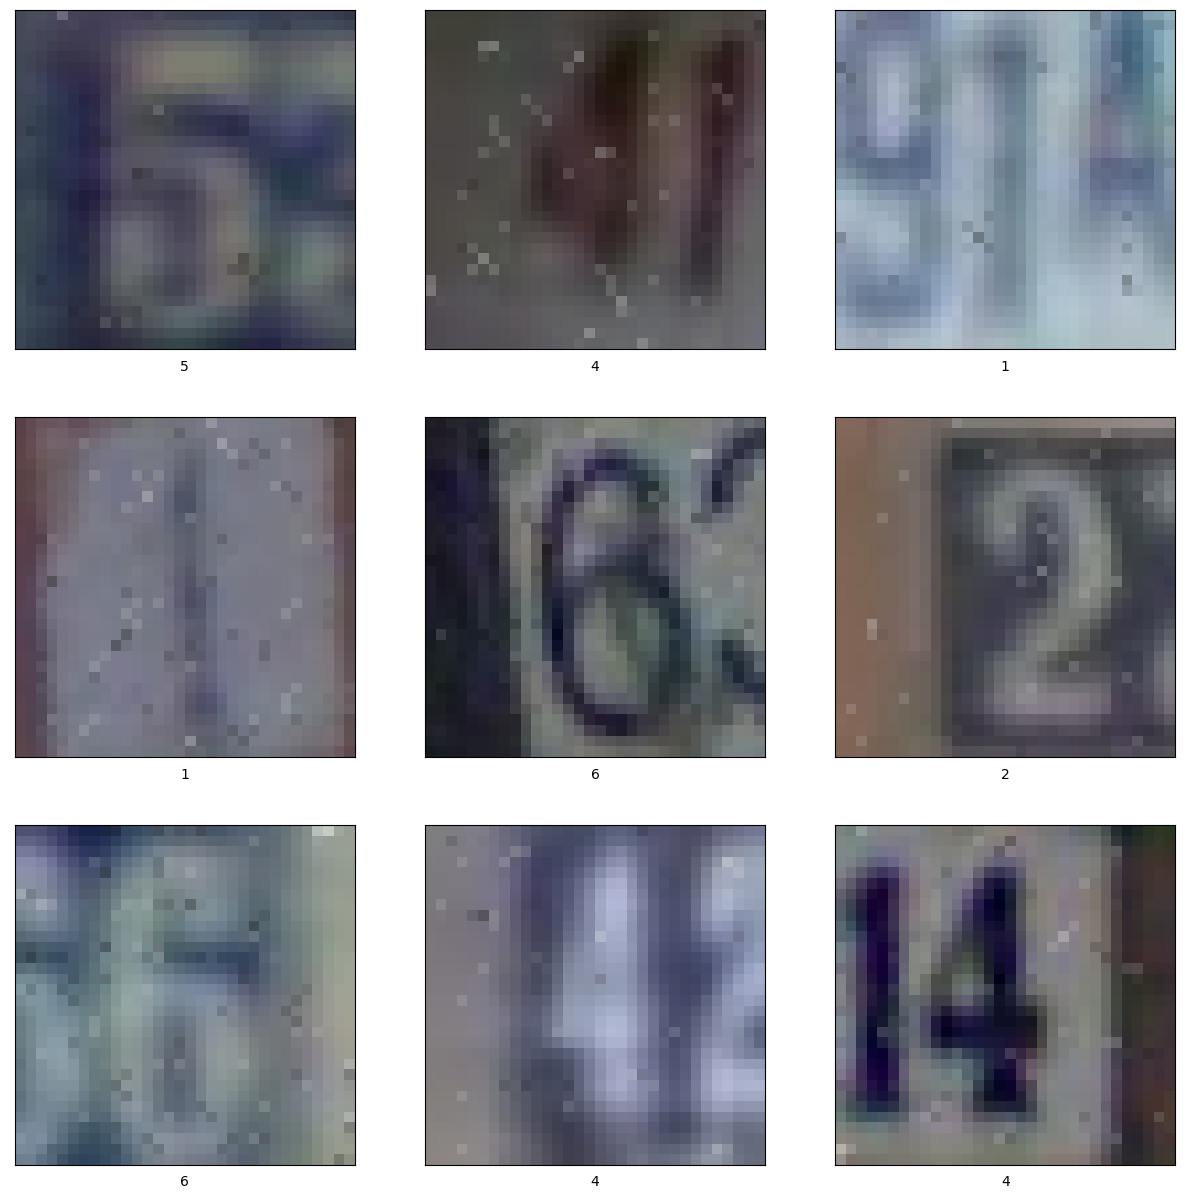

In [66]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arrtest[i]))
    plt.xlabel(classes[i])
plt.show()

In [67]:
with open('submissionadam5555.csv', 'w') as f:
    f.write('Id,Category\n')
    for i, j in enumerate(classes):
        f.write(f'{i},{j}\n')

In [31]:
f1 = 'submissionadam4.csv'
f2 = 'submissionadam5.csv'
for i, j in zip(open(f1, 'r').readlines(), open(f2, 'r').readlines()):
    if i != j:
        print(i, j)

4,6
 4,8

34,3
 34,7

42,3
 42,1

64,3
 64,8

67,3
 67,5

115,7
 115,2

137,3
 137,1

140,2
 140,7

141,9
 141,8

151,0
 151,6

167,4
 167,1

169,0
 169,8

175,6
 175,5

177,8
 177,9

178,3
 178,4

179,8
 179,9

182,9
 182,3

187,2
 187,0

198,3
 198,5

211,8
 211,6

219,8
 219,2

221,1
 221,8

223,9
 223,8

224,0
 224,1

232,3
 232,5

244,4
 244,1

245,4
 245,2

249,0
 249,6

252,3
 252,6

253,1
 253,2

254,7
 254,1

266,0
 266,3

269,2
 269,1

295,2
 295,4

313,4
 313,1

322,4
 322,8

324,2
 324,3

342,3
 342,2

345,8
 345,6

355,3
 355,5

359,7
 359,2

361,3
 361,1

365,2
 365,5

366,0
 366,9

374,1
 374,2

377,8
 377,6

390,1
 390,3

409,2
 409,4

411,2
 411,4

413,1
 413,5

423,6
 423,5

424,1
 424,2

455,3
 455,7

470,7
 470,2

488,4
 488,1

499,1
 499,6

511,3
 511,1

519,2
 519,3

523,0
 523,1

528,7
 528,2

531,1
 531,2

533,3
 533,1

561,4
 561,3

583,3
 583,5

592,0
 592,5

596,1
 596,3

601,8
 601,3

611,6
 611,8

614,2
 614,1

629,3
 629,5

631,4
 631,1

638,2
 638,4

644,

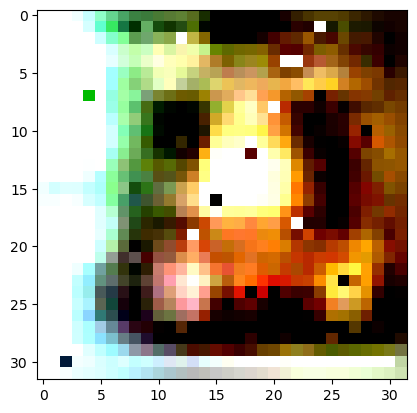

In [40]:

plt.imshow(np.array(arrtest[137]))
